# SPY — Classification Models (Iteration 4)

Walk-forward config: **train=15d / test=5d / embargo=2d** (~498 folds)

Predicts **price direction** (`target_direction`: Down=−1, Flat=0, Up=+1) using Logistic Regression and Random Forest.

SPY direction threshold: **±0.5%** (moves within ±0.5% are classified as Flat).

> **Note:** With train=15d and test=5d, only 1 fold is skipped (vs 537 in iter3). Accuracy improves to ~0.45 (vs ~0.39 in iter3), but still below the majority-class baseline. The embargo=2d gap reduces look-ahead leakage risk.

In [1]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix
)
from sklearn.exceptions import UndefinedMetricWarning

warnings.filterwarnings("ignore", category=UndefinedMetricWarning)
warnings.filterwarnings("ignore")

In [2]:
spy_raw = pd.read_csv("../data/SPY_features.csv", parse_dates=["date"], index_col="date")
print(f"SPY: {len(spy_raw):,} rows | {spy_raw.index[0].date()} → {spy_raw.index[-1].date()}")

SPY: 2,515 rows | 2015-01-02 → 2024-12-30


In [3]:
FEATURES = [
    "daily_return", "weekly_return", "lag_return_1", "lag_return_3", "lag_return_5",
    "dist_from_ma21", "ma_cross",
    "macd_hist",
    "daily_range", "volatility_20", "bb_position",
    "volume_change", "volume_ratio",
    "rsi_14",
    "is_major_event", "is_earnings_week",
]

TRAIN_WINDOW = 15
TEST_WINDOW  = 5
EMBARGO      = 2


def walk_forward_splits(df, train_window=TRAIN_WINDOW, test_window=TEST_WINDOW, embargo=EMBARGO):
    splits = []
    n = len(df)
    start = 0
    while start + train_window + embargo + test_window <= n:
        train_idx  = list(range(start, start + train_window))
        test_start = start + train_window + embargo
        test_idx   = list(range(test_start, test_start + test_window))
        splits.append((train_idx, test_idx))
        start += test_window
    return splits


def prepare_data(df, target_col, train_idx, test_idx):
    X = df[FEATURES].values
    y = df[target_col].values
    X_train, y_train = X[train_idx], y[train_idx]
    X_test,  y_test  = X[test_idx],  y[test_idx]
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)
    return X_train, X_test, y_train, y_test, scaler


def soften_direction(pct_change, threshold):
    if pct_change > threshold:
        return 1
    elif pct_change < -threshold:
        return -1
    else:
        return 0


SEASON_MAP = {
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Fall",  10: "Fall",  11: "Fall",
    12: "Winter", 1: "Winter", 2: "Winter"
}

In [4]:
def run_logistic_regression(df):
    splits = walk_forward_splits(df)
    print("\n" + "="*55)
    print("LOGISTIC REGRESSION — Predicting price direction")
    print(f"Walk-forward: {len(splits)} folds  (train={TRAIN_WINDOW}d, test={TEST_WINDOW}d, embargo={EMBARGO}d)")
    print("="*55)
    fold_metrics, all_preds, agg_cm, fold_coefs, last_model = [], [], np.zeros((3, 3), dtype=int), [], None
    skipped = 0
    for fold, (train_idx, test_idx) in enumerate(splits, 1):
        X_train, X_test, y_train, y_test, _ = prepare_data(df, "target_direction", train_idx, test_idx)
        if len(np.unique(y_train)) < 2:
            skipped += 1
            continue
        model = LogisticRegression(max_iter=1000, C=0.1)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        report = classification_report(y_test, preds, output_dict=True, zero_division=0)
        fold_metrics.append({"fold": fold, "accuracy": accuracy_score(y_test, preds),
                              "precision": report["macro avg"]["precision"],
                              "recall": report["macro avg"]["recall"],
                              "f1": report["macro avg"]["f1-score"]})
        cm = confusion_matrix(y_test, preds, labels=[-1, 0, 1])
        agg_cm += cm
        for date, actual, pred in zip(df.index[test_idx], y_test, preds):
            all_preds.append({"date": date, "actual": actual, "predicted": pred})
        for feat, coef in zip(FEATURES, model.coef_[0]):
            fold_coefs.append({"fold": fold, "feature": feat, "value": coef})
        last_model = model
    if skipped:
        print(f"  (skipped {skipped} single-class folds — expected with train={TRAIN_WINDOW}d window)")
    metrics_df = pd.DataFrame(fold_metrics)
    preds_df   = pd.DataFrame(all_preds)
    coef_df    = pd.DataFrame(fold_coefs)
    print(f"\n  {'Metric':<12}  {'Mean':>8}  {'Std':>8}")
    print(f"  {'-'*32}")
    for col, label in [("f1", "F1"), ("precision", "Precision"), ("recall", "Recall"), ("accuracy", "Accuracy")]:
        print(f"  {label:<12}  {metrics_df[col].mean():>8.4f}  ± {metrics_df[col].std():>7.4f}")
    print("\n  Aggregate confusion matrix (all folds):")
    labels = ["Down", "Flat", "Up"]
    print(pd.DataFrame(agg_cm, index=[f"Actual {l}" for l in labels], columns=[f"Pred {l}" for l in labels]).to_string())
    return last_model, metrics_df, preds_df, coef_df

In [5]:
def run_random_forest(df):
    splits = walk_forward_splits(df)
    print("\n" + "="*55)
    print("RANDOM FOREST — Predicting price direction")
    print(f"Walk-forward: {len(splits)} folds  (train={TRAIN_WINDOW}d, test={TEST_WINDOW}d, embargo={EMBARGO}d)")
    print("="*55)
    fold_metrics, all_preds, agg_cm, fold_coefs, last_model = [], [], np.zeros((3, 3), dtype=int), [], None
    skipped = 0
    for fold, (train_idx, test_idx) in enumerate(splits, 1):
        X_train, X_test, y_train, y_test, _ = prepare_data(df, "target_direction", train_idx, test_idx)
        if len(np.unique(y_train)) < 2:
            skipped += 1
            continue
        model = RandomForestClassifier(n_estimators=100, random_state=42)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        report = classification_report(y_test, preds, output_dict=True, zero_division=0)
        fold_metrics.append({"fold": fold, "accuracy": accuracy_score(y_test, preds),
                              "precision": report["macro avg"]["precision"],
                              "recall": report["macro avg"]["recall"],
                              "f1": report["macro avg"]["f1-score"]})
        cm = confusion_matrix(y_test, preds, labels=[-1, 0, 1])
        agg_cm += cm
        for date, actual, pred in zip(df.index[test_idx], y_test, preds):
            all_preds.append({"date": date, "actual": actual, "predicted": pred})
        for feat, imp in zip(FEATURES, model.feature_importances_):
            fold_coefs.append({"fold": fold, "feature": feat, "value": imp})
        last_model = model
    if skipped:
        print(f"  (skipped {skipped} single-class folds — expected with train={TRAIN_WINDOW}d window)")
    metrics_df = pd.DataFrame(fold_metrics)
    preds_df   = pd.DataFrame(all_preds)
    coef_df    = pd.DataFrame(fold_coefs)
    print(f"\n  {'Metric':<12}  {'Mean':>8}  {'Std':>8}")
    print(f"  {'-'*32}")
    for col, label in [("f1", "F1"), ("precision", "Precision"), ("recall", "Recall"), ("accuracy", "Accuracy")]:
        print(f"  {label:<12}  {metrics_df[col].mean():>8.4f}  ± {metrics_df[col].std():>7.4f}")
    print("\n  Aggregate confusion matrix (all folds):")
    labels = ["Down", "Flat", "Up"]
    print(pd.DataFrame(agg_cm, index=[f"Actual {l}" for l in labels], columns=[f"Pred {l}" for l in labels]).to_string())
    return last_model, metrics_df, preds_df, coef_df

In [6]:
def seasonal_summary(preds_df, label=""):
    df = preds_df.copy()
    df["season"] = pd.to_datetime(df["date"]).dt.month.map(SEASON_MAP)
    header = f"SEASONAL BREAKDOWN — {label}" if label else "SEASONAL BREAKDOWN"
    print("\n" + "="*55)
    print(header)
    print("="*55)
    season_order = ["Spring", "Summer", "Fall", "Winter"]
    rows = []
    for season in season_order:
        s = df[df["season"] == season]
        if len(s) < 2:
            continue
        report = classification_report(s["actual"], s["predicted"], output_dict=True, zero_division=0)
        rows.append({"season": season, "n": len(s),
                     "f1":        round(report["macro avg"]["f1-score"], 4),
                     "precision": round(report["macro avg"]["precision"], 4),
                     "recall":    round(report["macro avg"]["recall"], 4),
                     "accuracy":  round(accuracy_score(s["actual"], s["predicted"]), 4)})
    print(pd.DataFrame(rows).to_string(index=False))
    return pd.DataFrame(rows)

In [7]:
# ── Targets ──────────────────────────────────────────────────────────────
spy_raw["target_direction"] = (
    spy_raw["close"].pct_change(1).shift(-1)
    .apply(lambda x: soften_direction(x, threshold=0.005))
)

required_cols = FEATURES + ["target_direction"]
spy_df = spy_raw.dropna(subset=required_cols).copy()

print(f"Rows after dropping NaN: {len(spy_df):,}")
print(f"Date range: {spy_df.index.min().date()} → {spy_df.index.max().date()}")
print(f"Walk-forward folds: {len(walk_forward_splits(spy_df))}")
print(f"\ntarget_direction distribution:")
print(spy_df["target_direction"].value_counts().sort_index().rename({-1: "Down (-1)", 0: "Flat (0)", 1: "Up (1)"}))

# ── Run models ────────────────────────────────────────────────────────────
log_model, log_metrics, log_preds, log_coefs = run_logistic_regression(spy_df)
seasonal_summary(log_preds, "Logistic Regression — SPY")

rf_model,  rf_metrics,  rf_preds,  rf_coefs  = run_random_forest(spy_df)
seasonal_summary(rf_preds, "Random Forest — SPY")

Rows after dropping NaN: 2,515
Date range: 2015-01-02 → 2024-12-30
Walk-forward folds: 499

target_direction distribution:
target_direction
Down (-1)     551
Flat (0)     1263
Up (1)        701
Name: count, dtype: int64

LOGISTIC REGRESSION — Predicting price direction
Walk-forward: 499 folds  (train=15d, test=5d, embargo=2d)
  (skipped 1 single-class folds — expected with train=15d window)

  Metric            Mean       Std
  --------------------------------
  F1              0.3074  ±  0.2451
  Precision       0.2951  ±  0.2600
  Recall          0.3899  ±  0.2432
  Accuracy        0.4510  ±  0.2740

  Aggregate confusion matrix (all folds):
             Pred Down  Pred Flat  Pred Up
Actual Down        140        246      153
Actual Flat        214        796      246
Actual Up          205        303      187

SEASONAL BREAKDOWN — Logistic Regression — SPY
season   n     f1  precision  recall  accuracy
Spring 638 0.4049     0.4057  0.4045    0.4467
Summer 640 0.3540     0.3550  0.35

,season,n,f1,precision,recall,accuracy
0,Spring,638,0.3913,0.3916,0.3912,0.4279
1,Summer,640,0.3493,0.3503,0.3517,0.4469
2,Fall,630,0.3971,0.3985,0.4039,0.4683
3,Winter,582,0.3609,0.3613,0.3627,0.4175


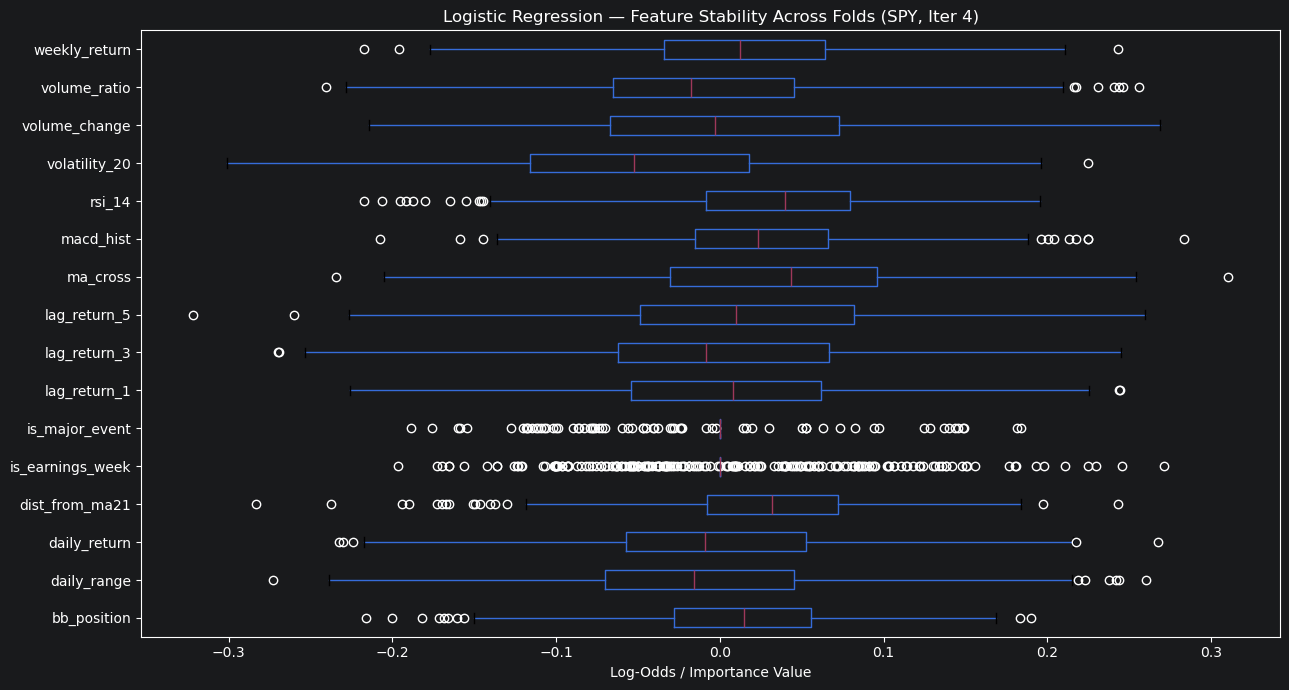

Saved: img/spy_iter4_logistic_regression_coef_stability.png


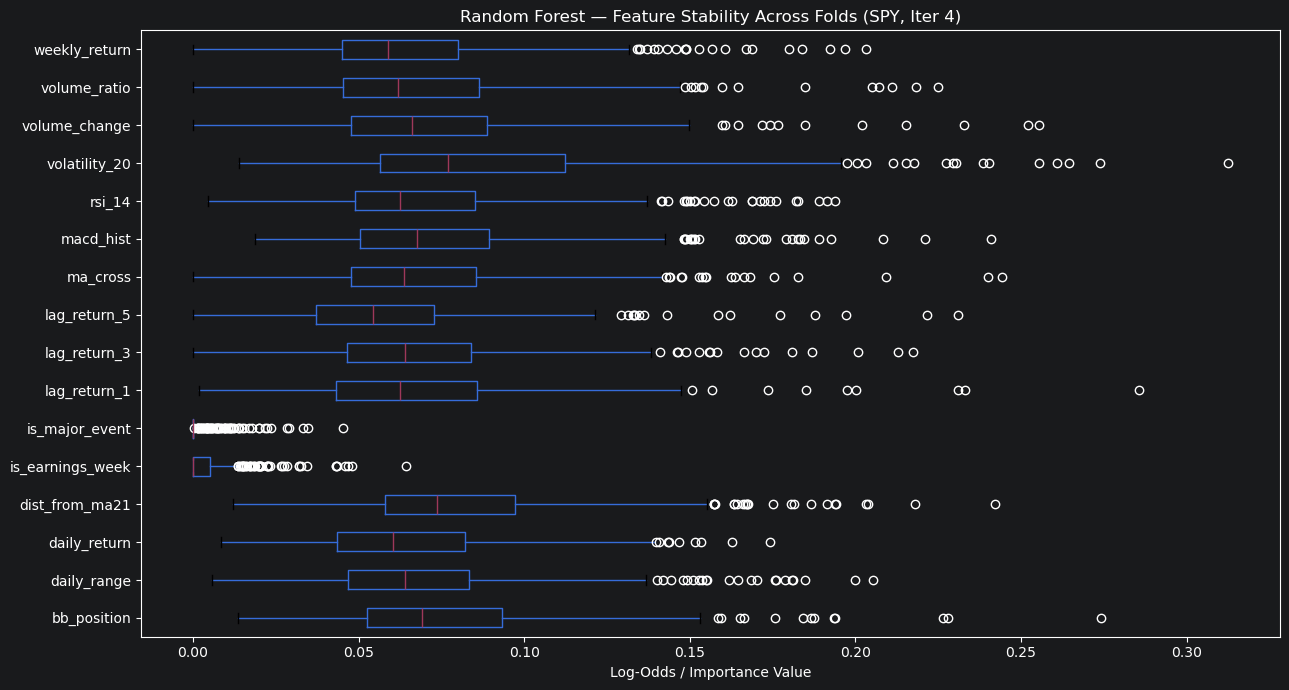

Saved: img/spy_iter4_random_forest_coef_stability.png


In [8]:
# ── COEFFICIENT / FEATURE IMPORTANCE STABILITY ───────────────────────────
for coef_df, label, color in [
    (log_coefs, "Logistic Regression", "steelblue"),
    (rf_coefs,  "Random Forest",       "seagreen"),
]:
    pivot = coef_df.pivot(index="fold", columns="feature", values="value")
    fig, ax = plt.subplots(figsize=(13, 7))
    pivot.boxplot(ax=ax, vert=False, grid=False)
    ax.set_title(f"{label} — Feature Stability Across Folds (SPY, Iter 4)")
    ax.set_xlabel("Log-Odds / Importance Value")
    plt.tight_layout()
    fname = label.lower().replace(" ", "_")
    plt.savefig(f"img/spy_iter4_{fname}_coef_stability.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: img/spy_iter4_{fname}_coef_stability.png")

## Red Flags — Iteration 4 (SPY Classification)

| Issue | Detail |
|---|---|
| **Accuracy improvement over iter3, but still low** | Logistic: accuracy≈0.45; RF: accuracy≈0.44. Better than iter3's ~0.39, but the majority-class baseline (always predict Flat) would yield ~50%. Models aren't learning useful signal. |
| **F1 near 0.31 for both models** | Low F1 (vs 0.33 random) means precision and recall are both weak. The confusion matrices show heavy Flat bias — models predict Flat on most test days, consistent with the class imbalance in the training window. |
| **Only 1 fold skipped** | The longer 15d training window almost always contains multiple classes — a clear improvement over iter3's 537 skipped folds. But low skip rate does not imply model quality. |
| **`is_major_event` / `is_earnings_week` always zero** | With only 15 training days, these rare event flags are almost never triggered. They contribute zero signal and should be excluded for short-window configs. |
| **Metric std still high** | Accuracy std≈0.27 indicates substantial fold-to-fold variance — the model is reliable in some windows and near-random in others. |
| **Iter4 vs iter2** | Iter2 (train=63d) achieves logistic accuracy≈0.38 with std≈0.11 (more stable). Iter4 achieves higher mean accuracy (0.45) but with much higher std (0.27), suggesting instability over overfitting. |